In [1]:
import math
from math import ceil, sqrt
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
from hydrax.utils.files import get_data_path
import seaborn as sns

from matplotlib.ticker import FuncFormatter


sns.set_theme(style="whitegrid", rc={"figure.dpi": 300, "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10, "legend.fontsize": 8})


def extract_single_data(df):
    data = {}
    data["state_cost"] = df["state_cost"].to_numpy()
    data["success"] = df["success"].to_numpy()
    data["T_pos"] = np.array([eval(x) for x in df["qpos"]])[:, :3]
    data["control"] = np.array([eval(x) for x in df["control"]])
    data["domain_weights"] = np.array([eval(x) for x in df["domain_weights"]])
    dr = df["dr_samples"]
    if dr is not None:
        dr = {k: np.array(v) for k, v in dr.items()}
        data["dr_samples"] = dr
    return data

def extract_values(path, seeds, controllers, dr_strategies, aggregation) -> Dict[int, Dict[str, Dict[str, np.ndarray]]]:
    data: Dict[int, Dict[str, Dict[str, np.ndarray]]] = {}
    missing: list[str] = []

    for seed in seeds:
        data[seed] = {}
        for controller in controllers:
            for dr_strategy in dr_strategies:
                for agg in aggregation:
                    # file = path / f"{controller}/seed_{seed}_dr_{dr_strategy}_update_cov_True_agg_{agg}.csv"
                    file = path / f"seed_{seed}_{controller}_{dr_strategy}_{agg}.csv"
                    if not file.exists():
                        missing.append(str(file))
                        continue
                    df = pd.read_csv(file)
                    data[seed][f"{controller}_{dr_strategy}_{agg}"] = extract_single_data(df)

    if missing:
        print("[plot_seeds] Skipped missing files:\n  - " + "\n  - ".join(missing))
    # Safety: filter seeds with at least one controller present
    seeds_present = [s for s in seeds if len(data.get(s, {})) > 0]
    if not seeds_present:
        raise FileNotFoundError("No seed data found. Check paths and filenames.")
    return data


In [2]:
# path = get_data_path().parent / "experiments" / "online_dr_sim"
path = get_data_path() / "dr_sim" 
seeds = [42] 
controllers = ["anmtp"] #["anmtp", "mtp", "mpc"]
dr_strategies = ["evolutionary"] #["evolutionary", "uniform", "bayesian"]
aggregation = ["cvar"]  #["expectation", "average", "icvar"]
data = extract_values(path, seeds, controllers, dr_strategies, aggregation)

In [3]:
import pickle
pkl_path = path / f"seed_{seeds[0]}_anmtp_evolutionary_average.pkl"
with open(pkl_path, "rb") as f:
    logs = pickle.load(f)

In [8]:
dr_samples = []
weights = []
for step in logs:
    dr = step["dr_samples"]
    if dr is not None:
        step_data = np.array([np.array(v) for k, v in dr.items()])
        dr_samples.append(step_data)
    weight = step["domain_weights"]
    if weight is not None:
        weights.append(np.array(weight))

data = np.array(dr_samples)  # shape: (num_steps, 1,num_domains, dim)
data = data.squeeze(1)  # shape: (num_steps, num_domains, dim)
data = data[:,:,3:5,2]
print(data.shape)

(23, 16, 2)


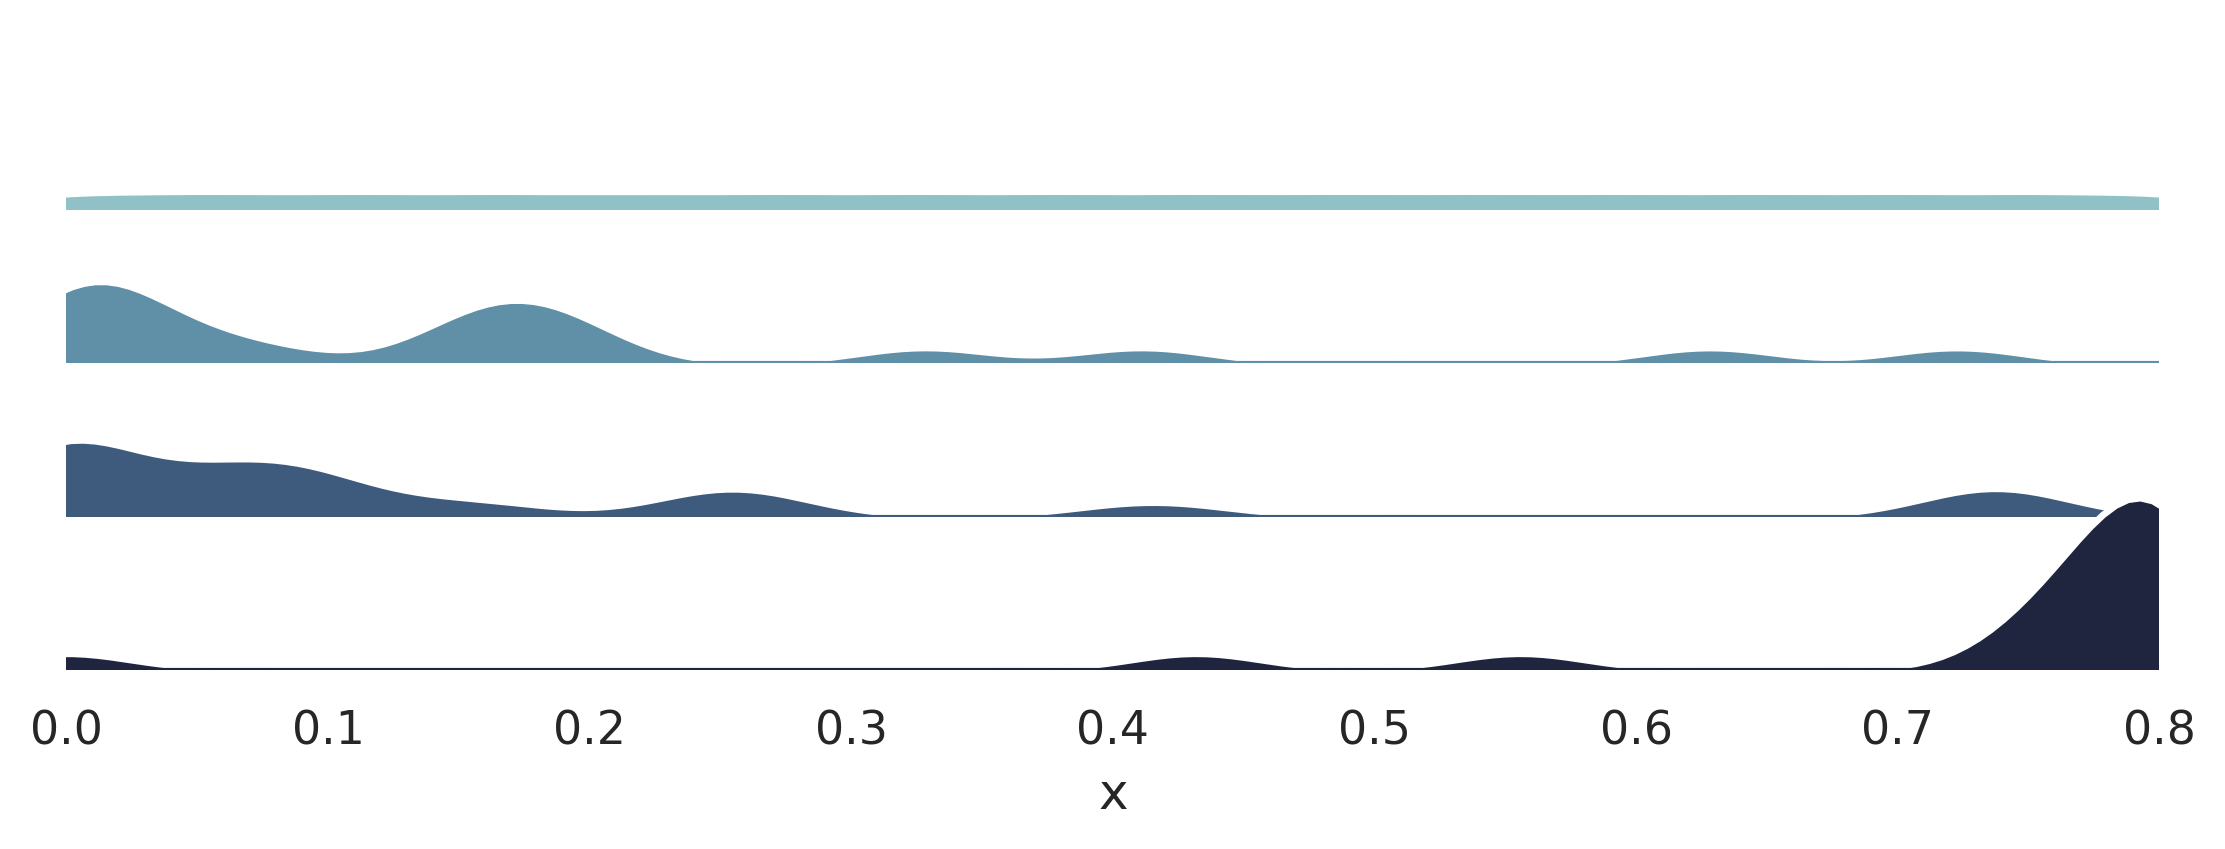

In [12]:
# steps = len(data[42]["anmtp_evolutionary_average"]["dr_samples"])
# X = data[42]["anmtp"]["dr_samples"]
X = data[...,0]
step_idx = [i * 5 for i in range(4)]  # Plot every 10 steps
steps, samples = X.shape
height=0.8
aspect=8
bw_adjust=0.2


if step_idx is None:
    step_idx = list(range(steps))
# Build long DataFrame
df = pd.DataFrame({
    "x": X[step_idx].ravel(),
    "step": np.repeat(step_idx, samples)
})
# Make string labels so FacetGrid preserves order nicely
df["label"] = pd.Categorical([f"{s}" for s in df["step"]], 
                                categories=[f"{s}" for s in step_idx],
                                ordered=True)

palette = sns.cubehelix_palette(len(step_idx), rot=-0.25, light=0.7)

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(df, row="label", hue="label", aspect=aspect/height, height=height, palette=palette)

# Filled KDE and outline
g.map(sns.kdeplot, "x", bw_adjust=bw_adjust, clip_on=True, fill=True, alpha=1, linewidth=1.25)
g.map(sns.kdeplot, "x", bw_adjust=bw_adjust, clip_on=True, color="w", lw=1.6)

# Baseline per ridge
g.refline(y=0, linewidth=1.0, linestyle="-", color=None, clip_on=True)

# Inline ridge labels
def _label(x, color, label, **kws):
    ax = plt.gca()
    ax.set_xlim(0.0, 0.8)
    # ax.text(0, 0.2, label, fontweight="bold", color=color,
    #         ha="left", va="center", transform=ax.transAxes)

g.map(_label, "x")

g.figure.subplots_adjust(hspace=-0.15)
g.set_titles("")
g.set(yticks=[], ylabel="")
# no x label
g.set_xlabels(None)
g.despine(left=True, bottom=True)
g.despine(bottom=True, left=True)
plt.show()

(35, 10)
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


/tmp/ipykernel_1468713/2667003894.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


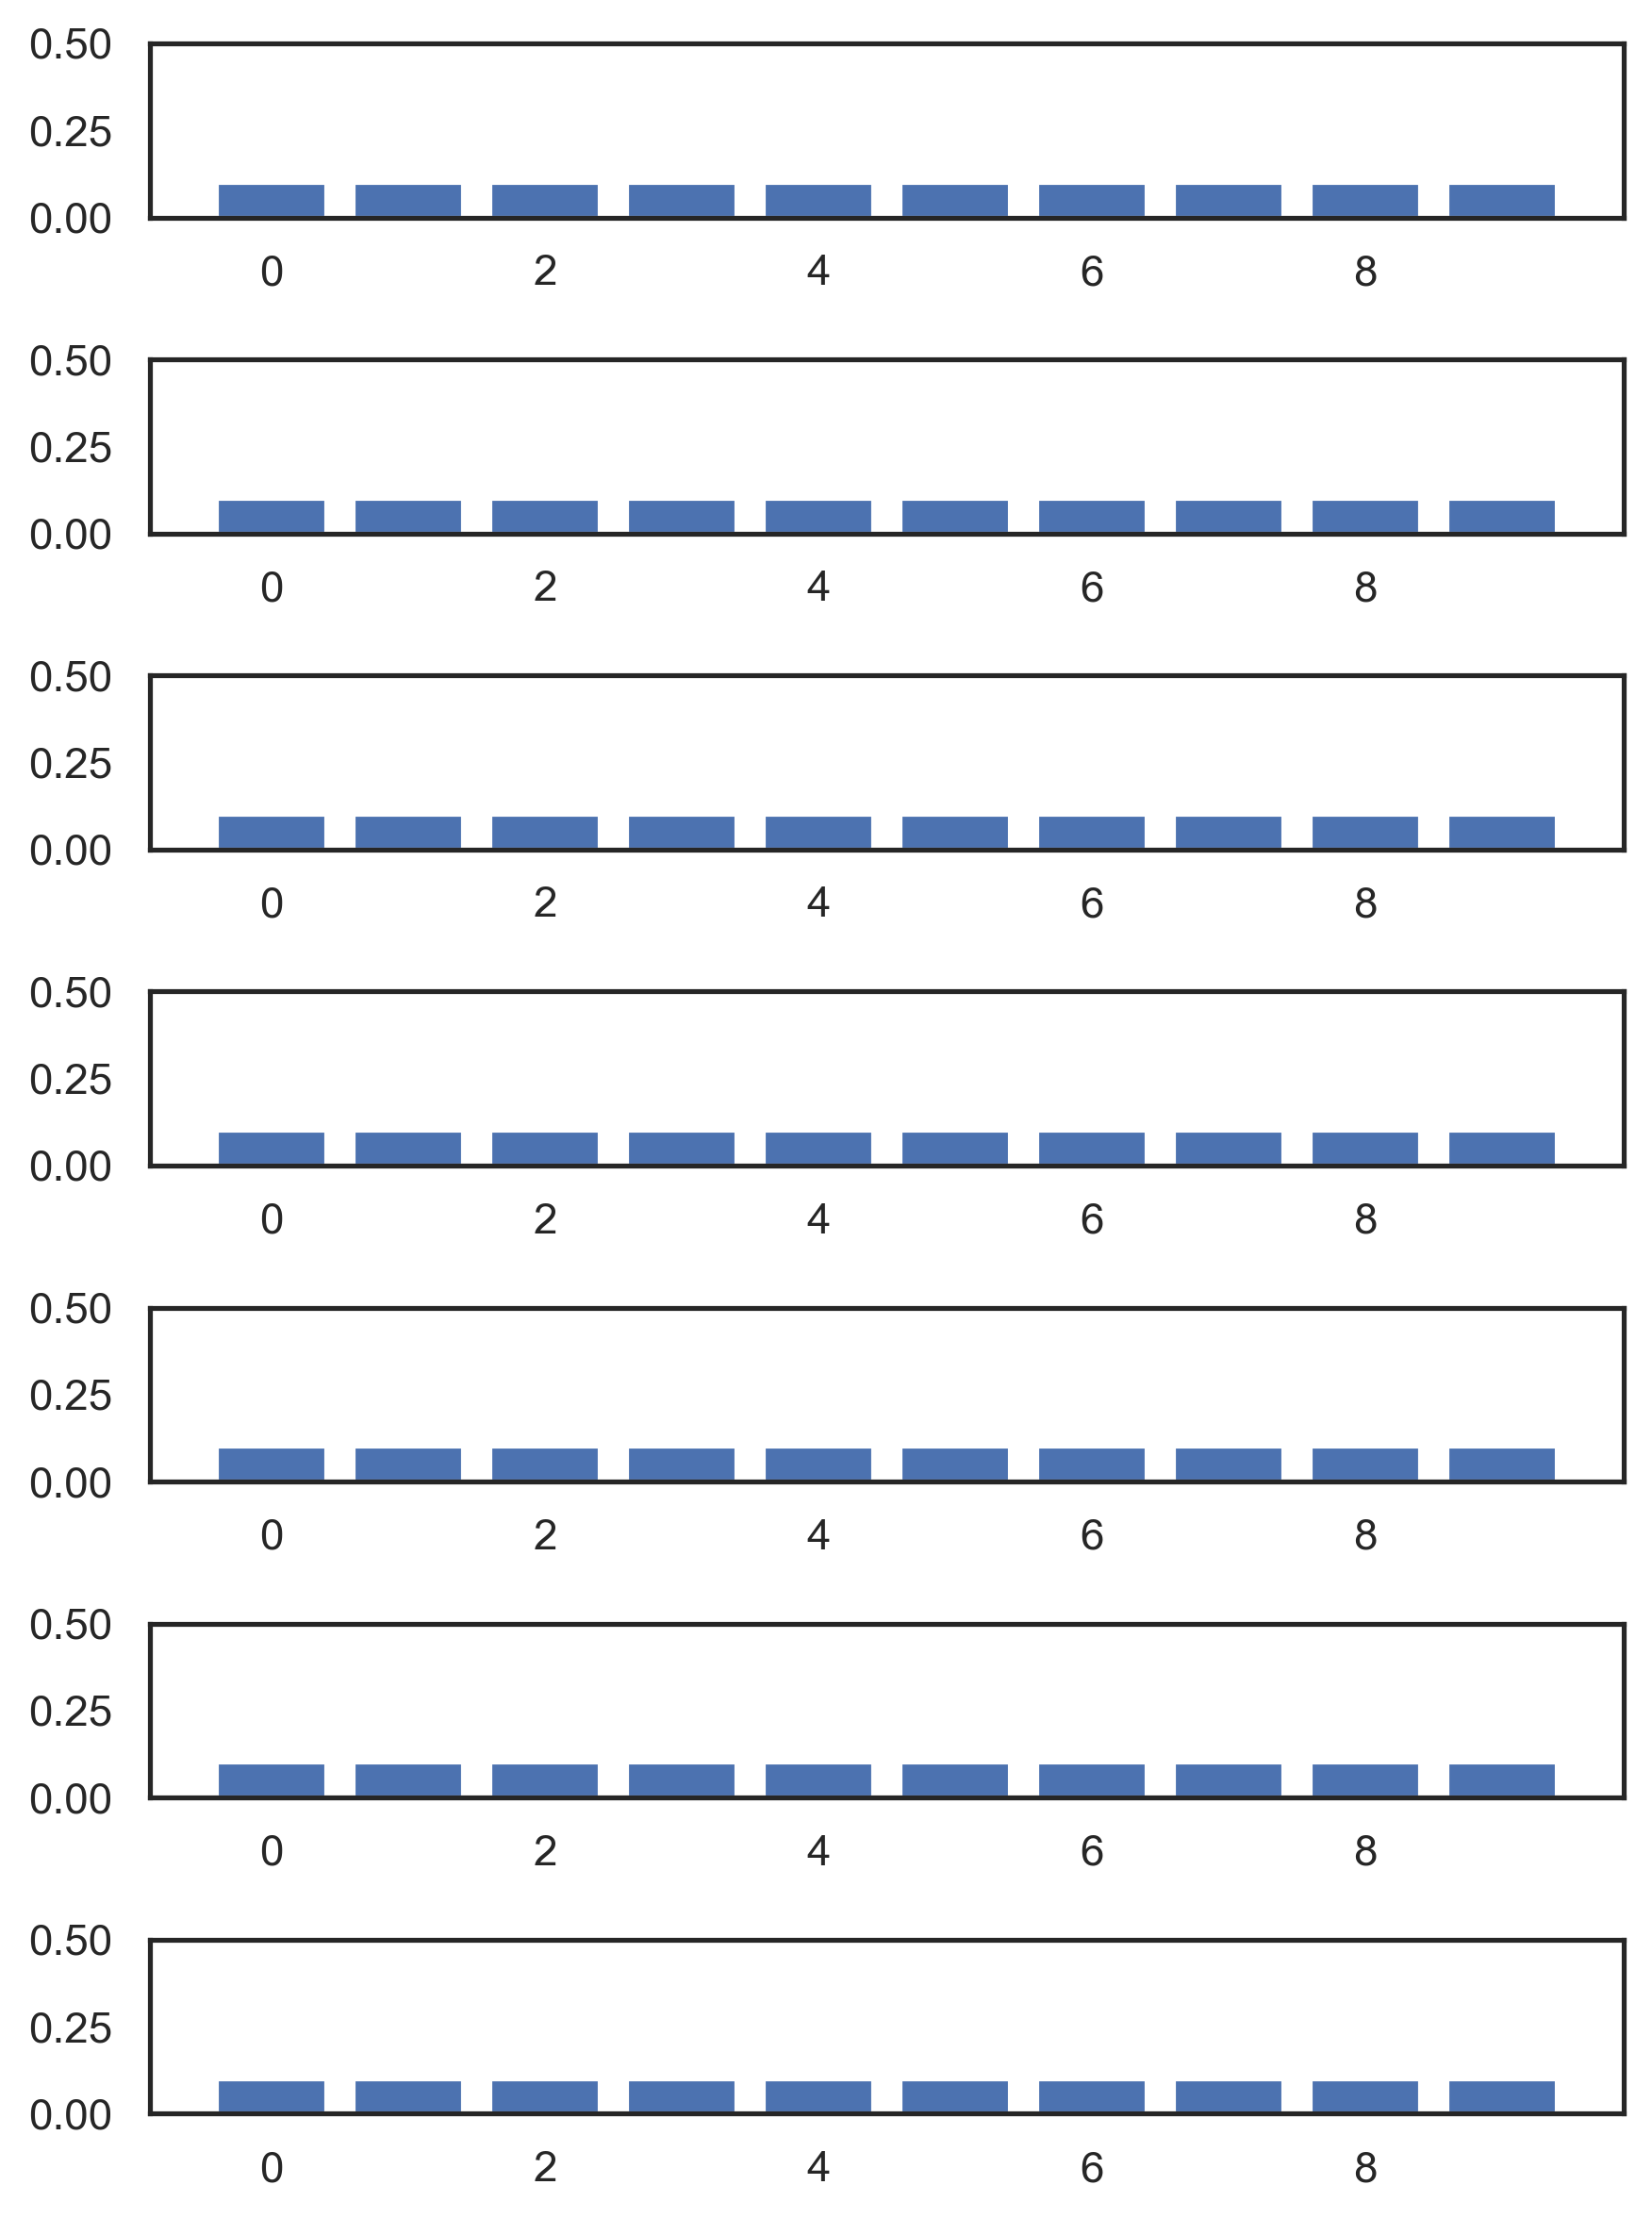

In [ ]:
data_2 = np.array(weights)
print(data_2.shape)
# create bar plot for every tenth timestep
step_idx = [i * 5 for i in range(7)]  # Plot every 10 steps
indices = np.arange(data_2.shape[1])  # number of domains
fig, axes = plt.subplots(nrows=len(step_idx), ncols=1, figsize=(6, 8), constrained_layout=True)
for i, ax in enumerate(axes):
    print(data_2[step_idx[i], :])
    ax.bar(np.arange(10), data_2[step_idx[i], :])
    ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()


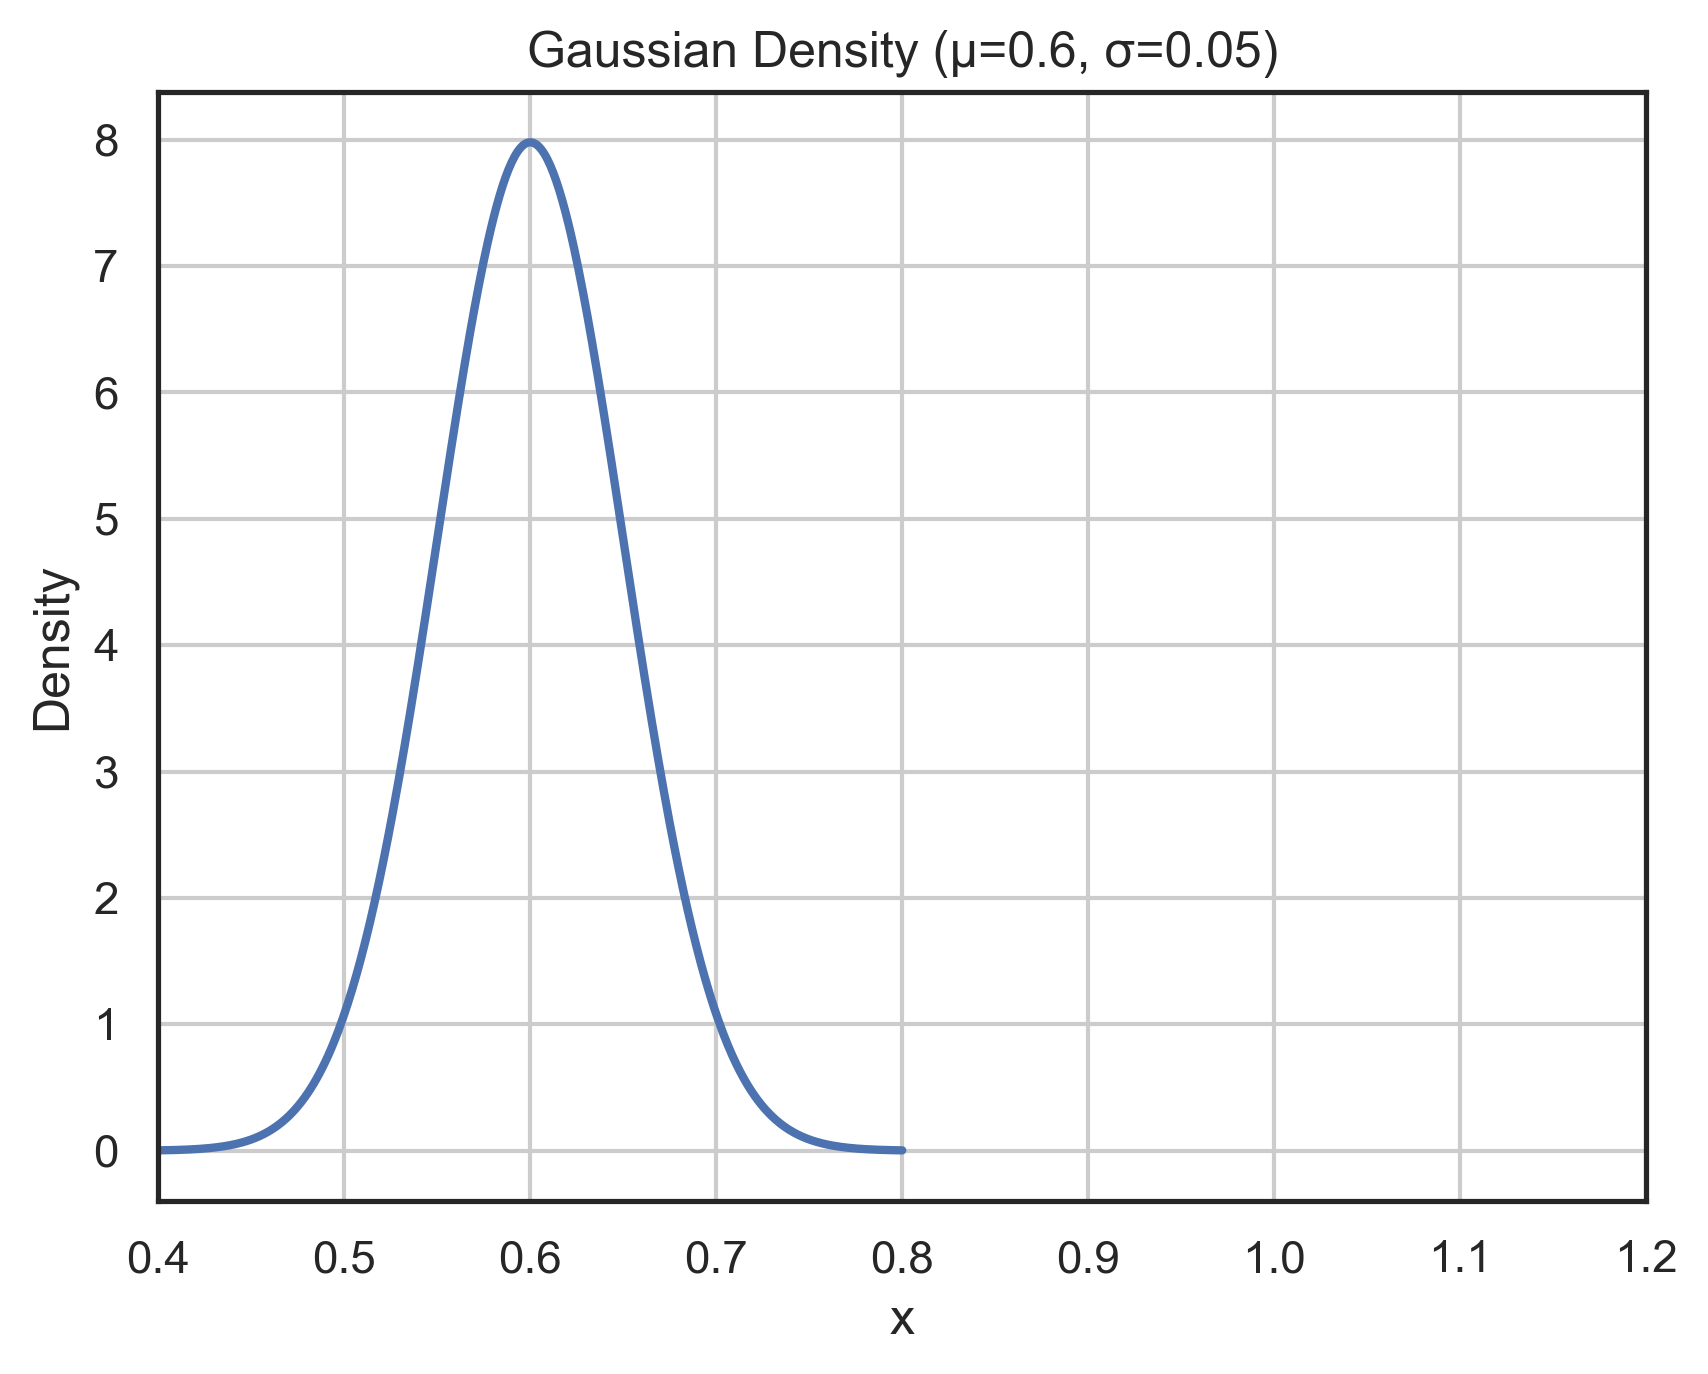

In [ ]:
from scipy.stats import norm

# Parameters
mu = 0.6      # mean
sigma = 0.05   # standard deviation

# Range for x-axis
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

# Gaussian density
y = norm.pdf(x, mu, sigma)

# Plot
plt.plot(x, y, linewidth=2)
plt.xlim(0.4, 1.2)
plt.title(f"Gaussian Density (μ={mu}, σ={sigma})")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()